In [1]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import time as t
from PIL import Image

In [ ]:
core = openmc.Material(1, "core", temperature=294)
# Add nuclides to core
core.add_nuclide('Pu239', 0.94, "wo")
core.add_nuclide('Pu240', 0.05, "wo")
core.add_nuclide('Ga69', 0.01, "wo")
core.set_density('g/cm3', 15.7)

coreCoating = openmc.Material(2, "Coat", temperature=294)
coreCoating.add_nuclide('Ni58', 1, "wo")
coreCoating.set_density('g/cm3', 8.9)

#shield
shield = openmc.Material(3, "shield", temperature=294)
shield.add_nuclide('Be9', 1, "wo") # burde være 0.98 men ved ikke hvad de sidste to % skal være
shield.set_density('g/cm3',  1.845)

#luft
air = openmc.Material(4, "air")
air.add_nuclide('N14', 0.78, "ao")
air.add_nuclide('O16', 0.21, "ao")
air.add_nuclide('Ar40', 0.1, "ao")
air.set_density('g/cm3', 0.001225*1e-3)

#creating Materials() and exporting to xml
mats = openmc.Materials([core, coreCoating, shield, air])
mats.export_to_xml()


In [ ]:
openmc.config['cross_sections'] = "" #Path to cross section data

(Universe
 	ID             =	3
 	Name           =	
 	Geom           =	CSG
 	Cells          =	[8],
 [-21, 21],
 [-18, 24])

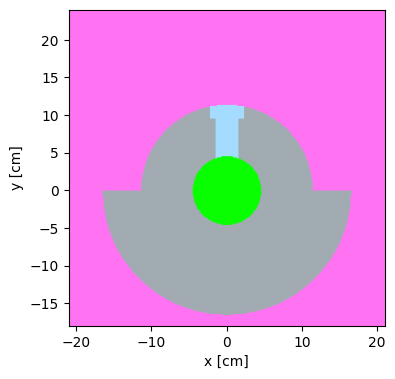

In [ ]:
colors = {
        1: (9, 255, 0),#"#09FF00",
        2: (0, 148, 0),#"#009400",
        3: (161, 171, 177),#"#a1abb1",
        5: (161, 171, 177),#"#a1abb1",
        6: (164, 220, 255),#"#a4dcff",
        7: (255, 115, 243),#"#ff73f3",
    }

def makeCore(φ, plot=True, noAir=False):
    φ += 0.000000000001
    rad = φ*np.pi/180
    topR = 11.4 #11.4
    butR = 16.5 #16.5
    coreR = 4.55 #4.55


    inCore = openmc.Sphere(r=coreR-0.0127, x0=topR*np.cos(rad)-topR, y0=-topR*np.sin(rad))
    outCore = openmc.Sphere(r=coreR, x0=topR*np.cos(rad)-topR, y0=-topR*np.sin(rad))
    coreSplitT = openmc.YPlane(y0=-topR*np.sin(rad) + 0.0127)
    coreSplitB = openmc.YPlane(y0=-topR*np.sin(rad) - 0.0127)
    but2 = openmc.Sphere(r=butR, x0=topR*np.cos(rad)-topR, y0=-topR*np.sin(rad))
    planeBut = openmc.Plane(a=-1, b=-1/np.tan(rad), c=0, d=topR)


    top1 = openmc.Sphere(r=coreR)
    top2 = openmc.Sphere(r=topR)
    planeTop = openmc.YPlane(y0=0)

    airBall = openmc.Sphere(r=2*topR, x0=-topR)

    topHul = openmc.YCylinder(r=1.5)
    hulPlane = openmc.YPlane(y0=9.5)
    topHul2 = openmc.YCylinder(r=2.25)



    pitch = 48
    b = 30
    leftCore = openmc.XPlane(x0=-coreR-3+topR*np.cos(rad)-topR)
    rightCore = openmc.XPlane(x0=coreR+3+topR*np.cos(rad)-topR)
    bottomCore = openmc.YPlane(y0=-coreR-3-topR*np.sin(rad))
    topCore = openmc.YPlane(y0=coreR+3-topR*np.sin(rad))

    left = openmc.XPlane(x0=-(pitch+b)/2, boundary_type='vacuum')
    right = openmc.XPlane(x0=(pitch+b)/2, boundary_type='vacuum')
    bottom = openmc.YPlane(y0=-(pitch+b)/2, boundary_type='vacuum')
    top = openmc.YPlane(y0=(pitch+b)/2, boundary_type='vacuum')

    leftB = openmc.XPlane(x0=-pitch/2, boundary_type='vacuum')
    rightB = openmc.XPlane(x0=pitch/2, boundary_type='vacuum')
    bottomB = openmc.YPlane(y0=-pitch/2, boundary_type='vacuum')
    topB = openmc.YPlane(y0=pitch/2, boundary_type='vacuum')



    coreCell = openmc.Cell(1)
    coreCell.fill = core
    coreCell.region = -inCore & (+coreSplitT | -coreSplitB)

    coatCell = openmc.Cell(10)
    coatCell.fill = coreCoating
    coatCell.region = +leftCore & -rightCore & +bottomCore & -topCore & (+inCore | (-inCore & -coreSplitT & +coreSplitB))

    coreCoatCell = openmc.Cell(2, fill=openmc.Universe(cells=[coreCell, coatCell]), region=-outCore)



    bShieldCell = openmc.Cell(3)
    bShieldCell.fill = shield
    bShieldCell.region = +outCore & -but2 & +planeBut



    moderator = openmc.Cell(6)
    moderator.fill = air
    moderator.region = -airBall & (-planeTop | -top1 | (-topHul & -hulPlane) | (-topHul2 & +hulPlane & -top2)) & (-planeBut & +outCore)


    # Moving top
    tShieldCell = openmc.Cell(5)
    tShieldCell.fill = shield
    tShieldCell.region = +top1 & -top2 & +planeTop & ((+topHul & -hulPlane) | (+topHul2 & +hulPlane))

    
    boundBox = openmc.Cell(7)
    boundBox.fill = air
    boundBox.region = +left & -right & +bottom & -top & ((+but2 & +planeBut) | (-planeBut & (+airBall | (+top2 & +planeTop))))


    if(noAir):
        cell = openmc.Cell(8, fill=openmc.Universe(cells=[coreCoatCell, bShieldCell, tShieldCell]), region=+leftB & -rightB & +bottomB & -topB)
    else:
        cell = openmc.Cell(8, fill=openmc.Universe(cells=[coreCoatCell, bShieldCell, tShieldCell, moderator, boundBox]), region=+leftB & -rightB & +bottomB & -topB)
    cell.rotation = (0, 0, φ)
    cell.translation = (topR*np.cos(rad)-topR, topR*np.sin(rad), 0)

    root = openmc.Universe(cells=[cell])

    geom = openmc.Geometry()
    geom.root_universe = root
    geom.export_to_xml()

    if(plot): 
        ax = root.plot(
            colors = colors, 
            pixels = 100000,
            # background = (164, 220, 255)
            )
        ax.set_xlim(-21, 21)
        ax.set_ylim(-18, 24)
    return root, geom, [-21, 21], [-18, 24]

makeCore(0)

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=6.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=5.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/op

(Universe
 	ID             =	6
 	Name           =	
 	Geom           =	CSG
 	Cells          =	[8],
 [-21, 21],
 [-18, 24])

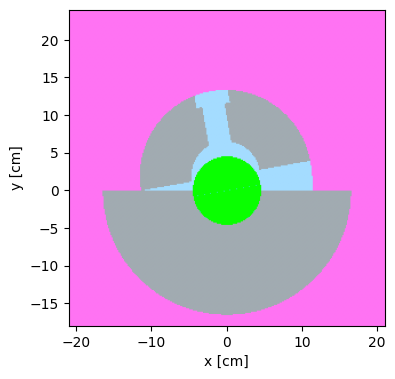

In [5]:
makeCore(10)
# makeCore(20)
# makeCore(30)
# makeCore(40)
# makeCore(50)

In [6]:
point = openmc.stats.Point((0, -0.1, 0))
src = openmc.IndependentSource(space=point)

settings = openmc.Settings()
settings.source = src
settings.batches = 100
settings.inactive = 10
settings.particles = 8000
settings.export_to_xml()

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=6.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=5.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/op

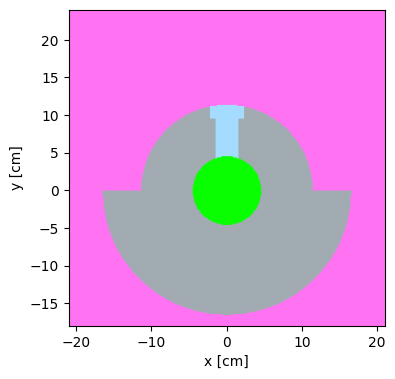

In [7]:
r, geom, xLim, yLim = makeCore(0)


In [21]:
def makeTally():
    tallies_file = openmc.Tallies()

    mesh = openmc.RegularMesh()
    mesh.dimension = [200, 200]
    mesh.lower_left = [xLim[0], yLim[0]]
    mesh.upper_right = [xLim[1], yLim[1]]

    # Create mesh filter for tally
    mesh_filter = openmc.MeshFilter(mesh)

    # Create mesh tally to score flux and fission rate
    tally = openmc.Tally(name='flux')
    tally.filters = [mesh_filter]
    tally.scores = ['flux', 'fission']
    tallies_file.append(tally)

    tallies_file.export_to_xml()
makeTally()

In [9]:
import os
os.system('rm s*h5')

openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [10]:
sp = openmc.StatePoint('statepoint.100.h5')
keff = sp.keff.nominal_value
keff_error = sp.keff.std_dev
print(keff,keff_error)

1.0015136782645189 0.0010978040403493313


Text(0.5, 0.98, '$k_{eff}$ = 1.00151 ± 0.0011')

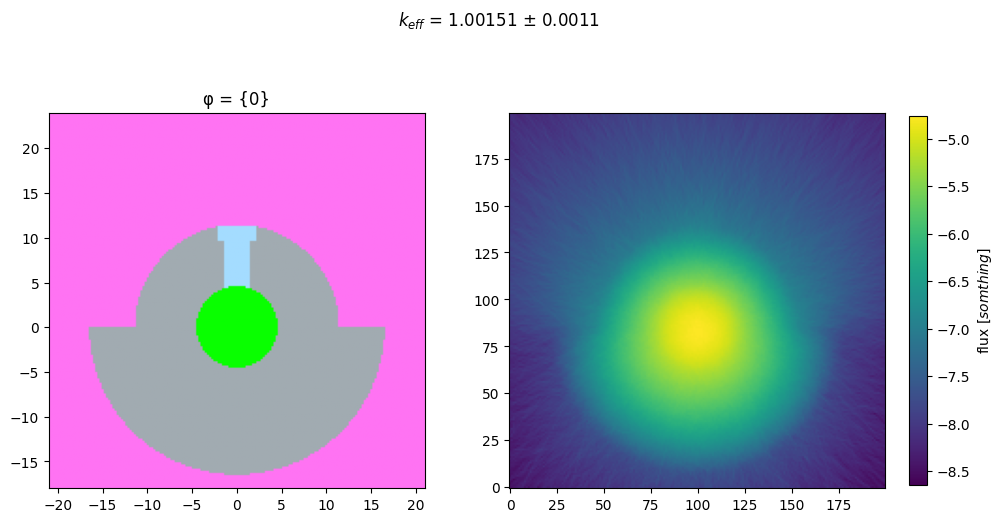

In [11]:
tally = sp.get_tally(scores=['flux'])

flux = tally.get_slice(scores=['flux'])
fission = tally.get_slice(scores=['fission'])

flux.std_dev.shape = (200, 200)
flux.mean.shape = (200, 200)

maxFlux = np.max(np.log(flux.mean))

fig, ax = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[0.8, 1])
geom.plot(axes=ax[0], colors=colors)
ax[0].set_xlim(xLim)
ax[0].set_ylim(yLim)
ax[0].set_title("φ = {0}")
img = ax[1].imshow(np.log(flux.mean))
# ax[1].imshow(1/(1-np.log(flux.mean)))
ax[1].invert_yaxis()
cbar = plt.colorbar(img, shrink=0.8)
cbar.set_label("flux $[somthing]$")
fig.suptitle("$k_{eff}$ = " + f"{round(keff,5)} ± {round(keff_error,5)}")

In [ ]:
gifPath = ""
endPath = ""
imgType = "jpeg"

phis = np.linspace(90, 0, 91)
# phis = []
# # phis = [80, 70, 60, 50, 40, 30, 20, 10, 0]


imgNames = []
for i in phis:
    r, g, _, _ = makeCore(i, plot=False)

    os.system('rm s*h5')
    openmc.run(output=False)
    
    sp = openmc.StatePoint('statepoint.100.h5')
    keff = sp.keff.nominal_value
    keff_error = sp.keff.std_dev
    
    tally = sp.get_tally(scores=['flux'])

    flux = tally.get_slice(scores=['flux'])
    fission = tally.get_slice(scores=['fission'])

    flux.std_dev.shape = (200, 200)
    flux.mean.shape = (200, 200)

    fig, ax = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[0.8, 1])
    g.plot(axes=ax[0], colors=colors)
    ax[0].set_xlim(xLim)
    ax[0].set_ylim(yLim)
    ax[0].set_title(f"φ = {i}")
    img = ax[1].imshow(np.log(flux.mean), vmin=-8.2, vmax=-6)#maxFlux)
    # ax[1].imshow(1/(1-np.log(flux.mean)))
    ax[1].invert_yaxis()
    cbar = plt.colorbar(img, shrink=0.8)
    cbar.set_label("log(flux) $[ab. units]$")
    fig.suptitle("$k_{eff}$ = " + f"{round(keff,5)} ± {round(keff_error,5)}")
    

    fig.savefig(gifPath + f"/frame{i}.{imgType}")
    imgNames.append(gifPath + f"/frame{i}.{imgType}")


frames = [Image.open(image) for image in imgNames]
frame_one = frames[0]
frame_one.save(endPath + f"/{t.time()}.gif", format="GIF", append_images=frames,
            save_all=True, duration=10, loop=0)

for i in glob.glob(f"{gifPath}/*.{imgType}"):   os.remove(i)  

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=6.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=5.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/op

In [ ]:
# plt.fill_between(phis, keffs+keffsErr, keffs-keffsErr)
# plt.plot(phis, keffs)

In [13]:
phis = np.linspace(90, 0, 91)
# phis = [80, 70, 60, 50, 40, 30, 20, 10, 0]

if(False): 
    makeTally()
else:
    try:
        os.system('rm tallies.xml')
    except: pass
    
keffs = []
keffsErr = []
for i in phis:
    makeCore(i, plot=False)

    os.system('rm s*h5')
    openmc.run(output=False)
    
    sp = openmc.StatePoint('statepoint.100.h5')
    keffs.append(sp.keff.nominal_value)
    keffsErr.append(sp.keff.std_dev)

keffs = np.array(keffs)
keffsErr = np.array(keffsErr)

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=6.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=5.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/op

(np.float64(0.0), np.float64(1.0))
1.0015136782645169
0.0010978040403500152


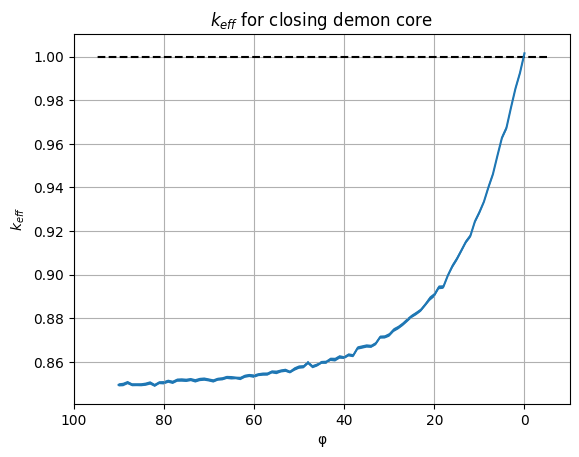

In [19]:
fig, ax = plt.subplots()
# bred = ax.get_ylim()
print(bred)
ax.hlines(1, xmin=-5, xmax=95, color="#000000", linestyle="--")
ax.fill_between(phis, keffs+keffsErr, keffs-keffsErr)
ax.plot(phis, keffs)
ax.invert_xaxis()

plt.title("$k_{eff}$ for closing demon core")
plt.xlabel("φ")
plt.ylabel("$k_{eff}$")
plt.grid()

fig.savefig(endPath + "/keff plot.png")
print(keffs[-1])
print(keffsErr[-1])

/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=10.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=2.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=3.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=6.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=5.
  warn(msg, IDWarning)
/home/alexa/ReactorFys_VE/lib/python3.12/site-packages/op

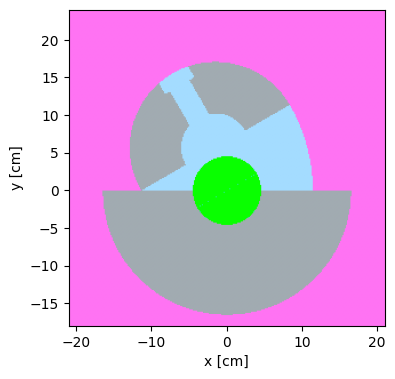

In [ ]:
r, g, xs, ys = makeCore(30, plot=True, noAir=False)


# a.from_geometry(g)
# a.type = 'voxel'
# a.width = (100., 100., 50.)
# a.pixels = (400, 400, 200)
# openmc.plot_inline()
# type(a)
# ipyImg = a.to_ipython_image()
# ipyImg




In [ ]:
a = openmc.VoxelPlot()
a.mask_components = [1]
a.pixels = [400, 400, 400]
a.width = [42, 42, 42]
a.origin = [0, 3, 0]
plotPath = a.to_vtk()
# openmc.plot

In [ ]:
import pyvista as pv

volume = pv.read(plotPath)
print(plotPath)

id = volume.cell_data.get_array("id")  

print(set(id))

pl = pv.Plotter()
id_a = volume.extract_values(1, scalars="id")
id_b = volume.extract_values(3, scalars="id")
id_c = volume.extract_values(5, scalars="id")
# id_b = volume.extract_values(5, scalars="id")

pl.add_mesh(id_a, color="light green", opacity=1)
pl.add_mesh(id_b, color="gray", opacity=0.9)
pl.add_mesh(id_c, color="gray", opacity=0.9)

pl.enable_parallel_projection()
# pl.show_grid()
pl.show()



plot_1.vti
{np.int32(1), np.int32(3), np.int32(5), np.int32(6), np.int32(7), np.int32(10)}


MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


Widget(value='<iframe src="http://localhost:45283/index.html?ui=P_0x7d2c7caecef0_0&reconnect=auto" class="pyvi…